This routine generates **Figure 2** and its supplementary panels for the paper *"Global Potential of Potable Reuse Across Coupled Climate and Socioeconomic Futures"*. If you have any questions please contact [a.sarfraz@uu.nl](mailto:a.sarfraz@uu.nl).

## Figure 2

Panels (a) through (d) show ensemble trajectories of the percentage reduction in regional municipal water withdrawal between 2025 and 2100, for four exemplar regions: the United States, the Middle East, Pakistan, and Japan. The solid line is the ensemble median; the shaded band is the interquartile range. The publication panels use full potable-reuse adoption (PR100); a PR50 counterpart and a paginated all-region grid are produced as supplementary outputs.

The world map that sits above panels (a) through (d) in the manuscript layout is rendered separately by `figure2_yearly_maps_individual_cividis`.

### Imports

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

### Setting directories

In [2]:
from __future__ import annotations

import sys
from pathlib import Path

import yaml

_NB_DIR   = Path.cwd()
REPO_ROOT = _NB_DIR.parent if _NB_DIR.name == "notebooks" else _NB_DIR

sys.path.insert(0, str(REPO_ROOT / "src"))

_cfg = yaml.safe_load((REPO_ROOT / "config" / "paths.yaml").read_text())

def _resolve(p):
    p = Path(p)
    return p if p.is_absolute() else (REPO_ROOT / p).resolve()

PATHS = {
    "data":    {k: _resolve(v) for k, v in _cfg["data"].items()},
    "outputs": {k: _resolve(v) for k, v in _cfg["outputs"].items()},
}

from potable_reuse.style import apply_style
from potable_reuse.plotting import save_all
apply_style()

DATA_DIR = PATHS["data"]["regional_reductions_dir"]
FIG_DIR  = PATHS["outputs"]["figure2_si"]
FIG_DIR.mkdir(parents=True, exist_ok=True)

### Loading cached data

Each `regional_reductions_PR{n}.parquet` file holds the percentage reduction in regional municipal water withdrawal for every (region, year, scenario) cell, computed against the matched PR0 baseline upstream of this notebook. We load PR50 and PR100 here.

In [3]:
def load_regional_reductions(pr_label):
    """Load the regional-reduction parquet for one PR level."""
    path = DATA_DIR / f"regional_reductions_{pr_label}.parquet"
    if not path.exists():
        raise FileNotFoundError(path)
    df = pd.read_parquet(path)
    df = df[df["pct_reduction"].notna()]
    return df


raw_pr50  = load_regional_reductions("PR50")
raw_pr100 = load_regional_reductions("PR100")

print(f"PR50  : {len(raw_pr50):,} rows | "
      f"{raw_pr50['region'].nunique()} regions")
print(f"PR100 : {len(raw_pr100):,} rows | "
      f"{raw_pr100['region'].nunique()} regions")

PR50  : 78,336 rows | 32 regions
PR100 : 78,336 rows | 32 regions


### Constants and helpers

Year window, PR-level palette (consistent with Figure 1), the four exemplar regions.

In [4]:
START_YEAR = 2025
END_YEAR   = 2100

PR_COLOR = {"PR50": "#1565C0", "PR100": "#2E7D32"}
ALPHA_IQR = 0.30

TARGET_REGIONS = [
    ("United States", ["USA", "United States"]),
    ("Middle East",   ["Middle East"]),
    ("Pakistan",      ["Pakistan"]),
    ("Japan",         ["Japan"]),
]


def _norm(s):
    return s.lower().replace("_", "").replace(" ", "")


def match_region(candidates, available):
    """Resolve a region label against the parquet's actual labels.
    Tries exact normalised match first, then substring fallback.
    Returns the canonical label found in `available`, or None."""
    norm = {_norm(r): r for r in available}
    for c in candidates:
        if _norm(c) in norm:
            return norm[_norm(c)]
    for c in candidates:
        nc = _norm(c)
        for k, v in norm.items():
            if nc in k or k in nc:
                return v
    return None

### Computing ensemble statistics

For each (region, year) we collapse the scenario ensemble into a median, an interquartile range, and a sample count. 

In [5]:
def ensemble_stats(df):
    """Per (region, year) ensemble statistics on `pct_reduction`."""
    df = df[(df["year"] >= START_YEAR) & (df["year"] <= END_YEAR)]
    return (df.groupby(["region", "year"], as_index=False)
              .agg(median=("pct_reduction", "median"),
                   q25=("pct_reduction", lambda s: s.quantile(0.25)),
                   q75=("pct_reduction", lambda s: s.quantile(0.75)),
                   mean=("pct_reduction", "mean"),
                   n=("pct_reduction", "size")))


ens_pr50  = ensemble_stats(raw_pr50)
ens_pr100 = ensemble_stats(raw_pr100)

print(f"ens_pr50  : {len(ens_pr50):,} rows | "
      f"{ens_pr50['region'].nunique()} regions")
print(f"ens_pr100 : {len(ens_pr100):,} rows | "
      f"{ens_pr100['region'].nunique()} regions")

ens_pr50  : 512 rows | 32 regions
ens_pr100 : 512 rows | 32 regions


### Figure 2 (b-e): exemplar regional trajectories

A 1-by-4 row of panels for the four exemplar regions, each showing the ensemble-median trajectory and its IQR ribbon. The publication output is PR100; a PR50 counterpart is produced for the Supplementary.

  Saved: fig2abcd_PR100_trajectories.png | fig2abcd_PR100_trajectories.svg | fig2abcd_PR100_trajectories.html


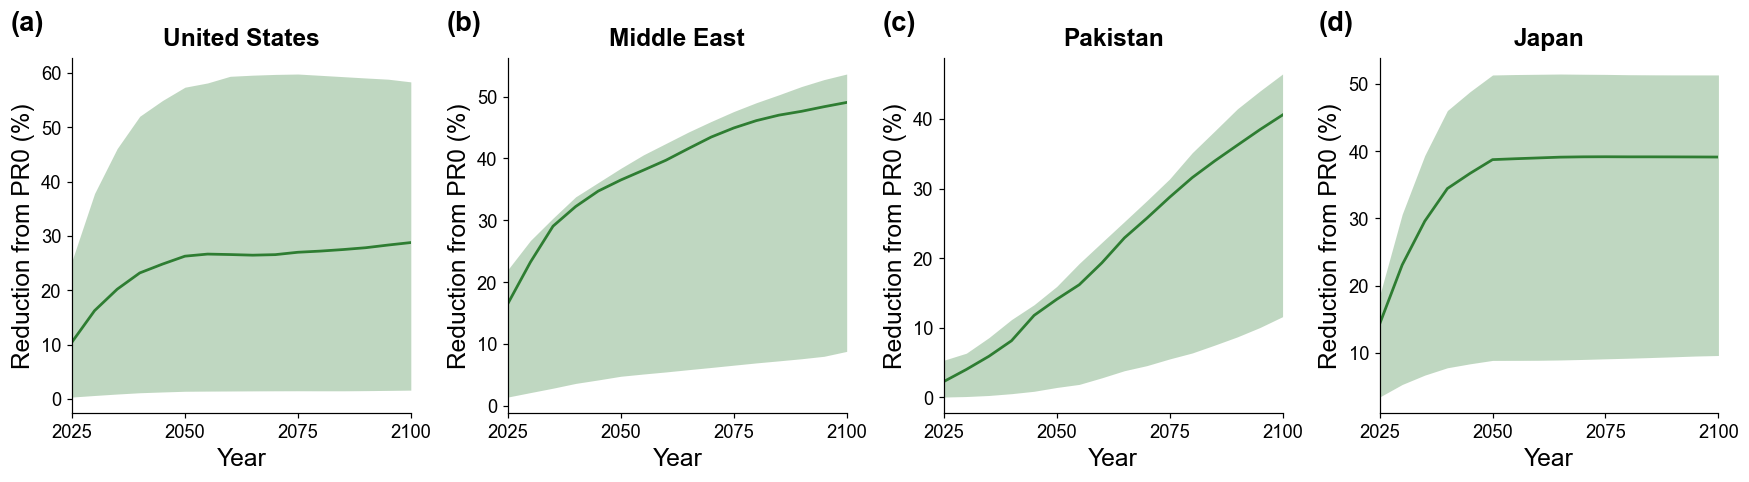

  Saved: figSI_PR50_trajectories.png | figSI_PR50_trajectories.svg | figSI_PR50_trajectories.html


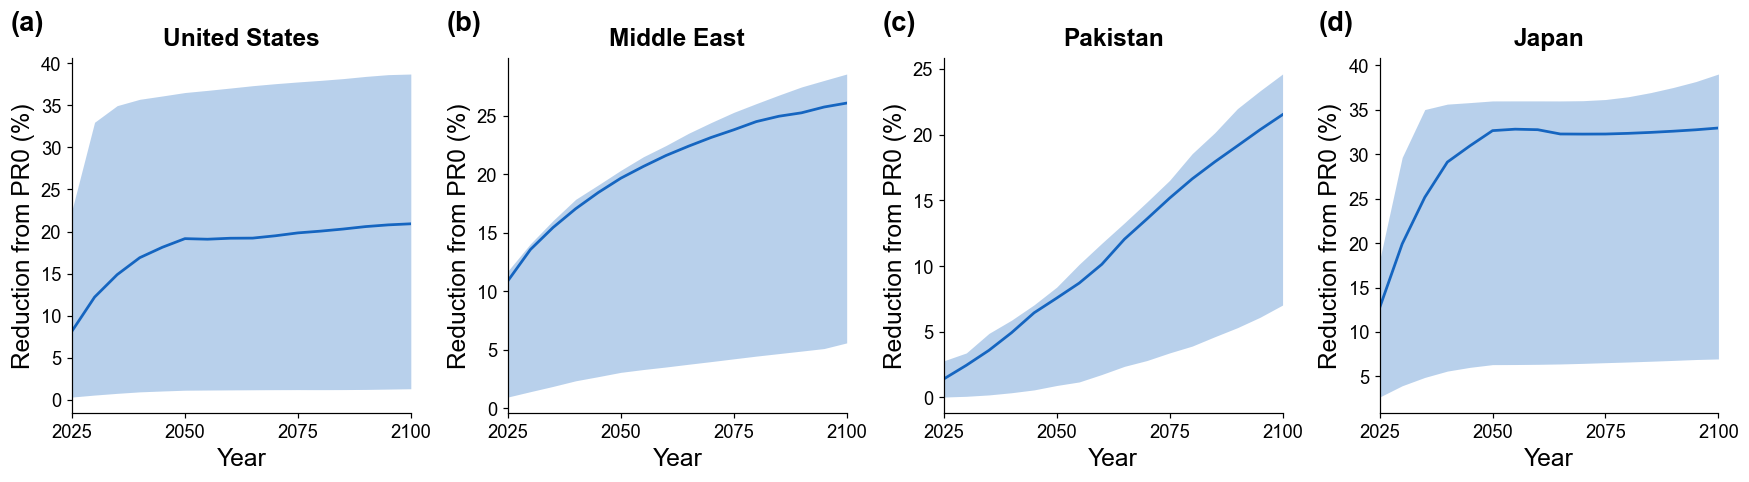

In [6]:
def plot_region_panel(ax, df_region, title, color):
    """Draw median line plus IQR ribbon for one region."""
    if df_region.empty:
        ax.text(0.5, 0.5, "no data",
                ha="center", va="center",
                transform=ax.transAxes, color="#888780")
        return
    ax.fill_between(df_region["year"],
                    df_region["q25"], df_region["q75"],
                    color=color, alpha=ALPHA_IQR, linewidth=0)
    ax.plot(df_region["year"], df_region["median"],
            color=color, linewidth=1.8)
    ax.set_title(title, fontweight="bold", pad=8)
    ax.set_xlabel("Year")
    ax.set_ylabel("Reduction from PR0 (%)")
    ax.set_xlim(START_YEAR, END_YEAR)
    ax.set_xticks([2025, 2050, 2075, 2100])


def figure_2_panels(ens, pr_label, out_stem):
    """1x4 row across the four exemplar regions."""
    available = sorted(ens["region"].unique())
    color     = PR_COLOR[pr_label]

    fig, axes = plt.subplots(1, 4, figsize=(16, 4.5),
                             sharex=False, sharey=False)

    for ax, (label, candidates) in zip(axes, TARGET_REGIONS):
        match = match_region(candidates, available)
        sub = (ens[ens["region"] == match]
               if match is not None else pd.DataFrame())
        plot_region_panel(ax, sub, title=label, color=color)

    for ax, letter in zip(axes, ["a", "b", "c", "d"]):
        ax.text(-0.18, 1.06, f"({letter})",
                transform=ax.transAxes,
                fontsize=18, fontweight="bold",
                va="bottom", ha="left")

    fig.tight_layout()
    save_all(fig, FIG_DIR, out_stem)
    plt.show()
    plt.close(fig)


# Figure 2 (a-d) main panel: PR100.
figure_2_panels(ens_pr100, "PR100", "fig2abcd_PR100_trajectories")

# Supplementary counterpart: PR50.
figure_2_panels(ens_pr50, "PR50", "figSI_PR50_trajectories")

### Headline numbers

End-of-century (2100) ensemble-median percentage reduction for every region under PR50 and PR100, sorted by the PR100 value. Useful for cross-checking the manuscript, which calls out Northern Africa, the Middle East, and Pakistan as the largest reducers and Indonesia, China, Ukraine, and northern South America as the smallest.

In [8]:
def end_of_century_table(ens_pr50, ens_pr100, year=2100):
    a = (ens_pr50[ens_pr50["year"] == year]
         [["region", "median"]]
         .rename(columns={"median": "PR50"}))
    b = (ens_pr100[ens_pr100["year"] == year]
         [["region", "median"]]
         .rename(columns={"median": "PR100"}))
    out = a.merge(b, on="region", how="outer")
    return out.sort_values("PR100", ascending=False).reset_index(drop=True)


table = end_of_century_table(ens_pr50, ens_pr100)

# Print and save.
lines = ["End-of-century (2100) ensemble-median % reductions",
         "=" * 56,
         f"{'Region':<28s}  {'PR50':>7s}  {'PR100':>7s}"]
for _, row in table.iterrows():
    lines.append(f"{row['region']:<28s}  "
                 f"{row['PR50']:7.1f}  {row['PR100']:7.1f}")
text = "\n".join(lines)
print(text)

out = FIG_DIR / "headline_numbers.txt"
out.write_text(text, encoding="utf-8")
print(f"\nWrote {out}")

End-of-century (2100) ensemble-median % reductions
Region                           PR50    PR100
Africa_Northern                  29.4     52.1
Middle East                      26.1     49.1
Pakistan                         21.5     40.6
Japan                            33.0     39.1
Australia_NZ                     29.8     36.7
Europe_Non_EU                    25.3     35.2
European Free Trade Association     28.4     34.7
India                            21.5     34.1
Central Asia                     22.1     34.0
South Africa                     24.2     32.4
EU-15                            25.0     32.4
Mexico                           23.1     31.4
EU-12                            23.0     30.2
Brazil                           22.9     29.7
Africa_Eastern                   19.4     28.8
USA                              20.9     28.8
South America_Southern           20.5     28.4
South Asia                       17.0     26.5
Central America and Caribbean     19.0     26.5
Afric

### regenarating SI figures - as per map scheme 


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

MULTI_PALETTE = [
    "#F6E8C3", "#DFC27D", "#DDCC77", "#99DDFF",
    "#77AADD", "#44BB99", "#BBCC33", "#228833",
    "#999933", "#CC6677", "#882255", "#332288",
]

def save_all(fig, out_dir, stem, dpi=300):
    out_dir = Path(out_dir); out_dir.mkdir(parents=True, exist_ok=True)
    fig.savefig(out_dir / f"{stem}.png", dpi=dpi, bbox_inches="tight")
    fig.savefig(out_dir / f"{stem}.svg", bbox_inches="tight")
    svg = (out_dir / f"{stem}.svg").read_text(encoding="utf-8")
    (out_dir / f"{stem}.html").write_text(
        f"<!doctype html><meta charset='utf-8'><title>{stem}</title>"
        f"<body style='margin:0;padding:1rem;font-family:system-ui'>{svg}</body>",
        encoding="utf-8",
    )

NCOLS = 4

def figure_si_all_regions(ens, pr_label, out_stem,
                          color=None, bin_index=7,
                          xlabel="Year",
                          ylabel="Reduction from PR0 (%)"):
    if color is None:
        bin_index = int(np.clip(bin_index, 0, len(MULTI_PALETTE) - 1))
        color     = MULTI_PALETTE[bin_index]

    available = sorted(ens["region"].unique())
    n_total   = len(available)
    nrows     = int(np.ceil(n_total / NCOLS))

    fig, axes = plt.subplots(
        nrows, NCOLS,
        figsize=(NCOLS * 1.55, nrows * 1.45),   # ~12.4 x 5.8 in for 4x8
        sharex=True, sharey=True,
        constrained_layout=True,                 # plays nicely with supxlabel/supylabel
    )
    axes_flat = np.atleast_1d(axes).flatten()

    for ax, region in zip(axes_flat, available):
        sub = ens[ens["region"] == region]
        plot_region_panel(ax, sub, title=region, color=color)

        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.set_title(region, fontsize=7, fontweight="bold", pad=2)
        ax.tick_params(axis="both", labelsize=6, length=2, pad=1)

    for ax in axes_flat[n_total:]:
        ax.set_visible(False)

    fig.supxlabel(xlabel, fontsize=9, fontweight="bold")
    fig.supylabel(ylabel, fontsize=9, fontweight="bold")
    fig.suptitle(
        f"{pr_label} regional trajectories — all {n_total} regions",
        fontweight="bold", fontsize=10,
    )

    save_all(fig, FIG_DIR, out_stem)
    plt.close(fig)
    print(f"Wrote {pr_label}: {nrows} x {NCOLS} grid, color={color}")

# -----------------------------------------------------------------
figure_si_all_regions(ens_pr100, "PR100", "figSI_PR100_all_regions",
                      bin_index=7)   # green
figure_si_all_regions(ens_pr50,  "PR50",  "figSI_PR50_all_regions",
                      bin_index=4)   # mid blue

Wrote PR100: 8 x 4 grid, color=#228833
Wrote PR50: 8 x 4 grid, color=#77AADD


In [10]:
# ============================================================
# Manuscript-ready stats for the Figure 2 paragraph
# Pulls medians and IQRs for every region at 2100, identifies
# the top and bottom rankers, reports the four exemplar regions
# in parallel (2025 start, 2100 end, plateau year if any),
# and computes the factor-of-N spread claim.
# ============================================================

def _band(median, q25, q75, fmt="{:.1f}"):
    """Format 'X.X% (IQR Y.Y to Z.Z%)' in one go."""
    return (f"{fmt.format(median)}% "
            f"(IQR {fmt.format(q25)} to {fmt.format(q75)}%)")


def detect_plateau(df_region, slope_thresh=0.1, window=3):
    """First year after which median slope stays below slope_thresh
    (percentage points per year) for `window` consecutive samples."""
    d = df_region.sort_values("year").reset_index(drop=True)
    if len(d) < window + 1:
        return None
    slopes = np.gradient(d["median"].values, d["year"].values)
    for i in range(len(d) - window):
        if np.all(np.abs(slopes[i:i + window]) < slope_thresh):
            return int(d["year"].iloc[i])
    return None


def manuscript_stats(ens_pr100, exemplars=None,
                     start_year=2025, end_year=2100, top_n=5):
    if exemplars is None:
        exemplars = TARGET_REGIONS
    available = sorted(ens_pr100["region"].unique())

    # --- 2100 ranking across all regions --------------------
    end = ens_pr100[ens_pr100["year"] == end_year].copy()
    end = end.sort_values("median", ascending=False).reset_index(drop=True)

    print("=" * 64)
    print(f"All regions at {end_year}, sorted by median (PR100)")
    print("=" * 64)
    print(f"{'Region':<28s}  {'median':>7s}  {'q25':>7s}  {'q75':>7s}")
    for _, r in end.iterrows():
        print(f"{r['region']:<28s}  "
              f"{r['median']:7.1f}  {r['q25']:7.1f}  {r['q75']:7.1f}")

    # --- Spread ---------------------------------------
    top   = end.head(top_n)
    bot   = end.tail(top_n).iloc[::-1]
    ratio = end["median"].iloc[0] / end["median"].iloc[-1]

    print("\n" + "=" * 64)
    print("Spread claim")
    print("=" * 64)
    print(f"Highest: {end.iloc[0]['region']} at "
          f"{_band(end.iloc[0]['median'], end.iloc[0]['q25'], end.iloc[0]['q75'])}")
    print(f"Lowest : {end.iloc[-1]['region']} at "
          f"{_band(end.iloc[-1]['median'], end.iloc[-1]['q25'], end.iloc[-1]['q75'])}")
    print(f"Ratio (max/min) = {ratio:.1f}x")

    print(f"\nTop {top_n}:")
    for _, r in top.iterrows():
        print(f"  {r['region']:<28s}  "
              f"{_band(r['median'], r['q25'], r['q75'])}")
    print(f"\nBottom {top_n}:")
    for _, r in bot.iterrows():
        print(f"  {r['region']:<28s}  "
              f"{_band(r['median'], r['q25'], r['q75'])}")

    # --- Exemplar regions ------------------
    print("\n" + "=" * 64)
    print("Exemplar regions (parallel reporting for the paragraph)")
    print("=" * 64)
    for label, candidates in exemplars:
        match = match_region(candidates, available)
        if match is None:
            print(f"\n{label}: NO MATCH in parquet")
            continue
        sub = ens_pr100[ens_pr100["region"] == match]
        s_row = sub[sub["year"] == start_year]
        e_row = sub[sub["year"] == end_year]
        if s_row.empty or e_row.empty:
            print(f"\n{label}: missing endpoints")
            continue
        s = s_row.iloc[0]
        e = e_row.iloc[0]
        plateau_year = detect_plateau(sub)

        print(f"\n{label} ({match})")
        print(f"  {start_year}: {_band(s['median'], s['q25'], s['q75'])}")
        print(f"  {end_year}: {_band(e['median'], e['q25'], e['q75'])}")
        if plateau_year is not None:
            p_row = sub[sub["year"] == plateau_year].iloc[0]
            print(f"  plateau onset: ~{plateau_year} at "
                  f"{_band(p_row['median'], p_row['q25'], p_row['q75'])}")
        else:
            print(f"  plateau onset: none detected "
                  f"(slope > 0.1 pp/yr throughout)")


manuscript_stats(ens_pr100)

All regions at 2100, sorted by median (PR100)
Region                         median      q25      q75
Africa_Northern                  52.1      8.6     60.2
Middle East                      49.1      8.8     53.7
Pakistan                         40.6     11.6     46.5
Japan                            39.1      9.6     51.3
Australia_NZ                     36.7      7.0     52.0
Europe_Non_EU                    35.2      3.2     56.2
European Free Trade Association     34.7      5.9     51.4
India                            34.1      2.9     45.1
Central Asia                     34.0      1.7     55.8
South Africa                     32.4      3.6     53.9
EU-15                            32.4      3.7     54.7
Mexico                           31.4      3.2     53.8
EU-12                            30.2      3.1     54.3
Brazil                           29.7      3.4     51.4
Africa_Eastern                   28.8      4.6     42.7
USA                              28.8      1.6     58.3

### updated color sequence 

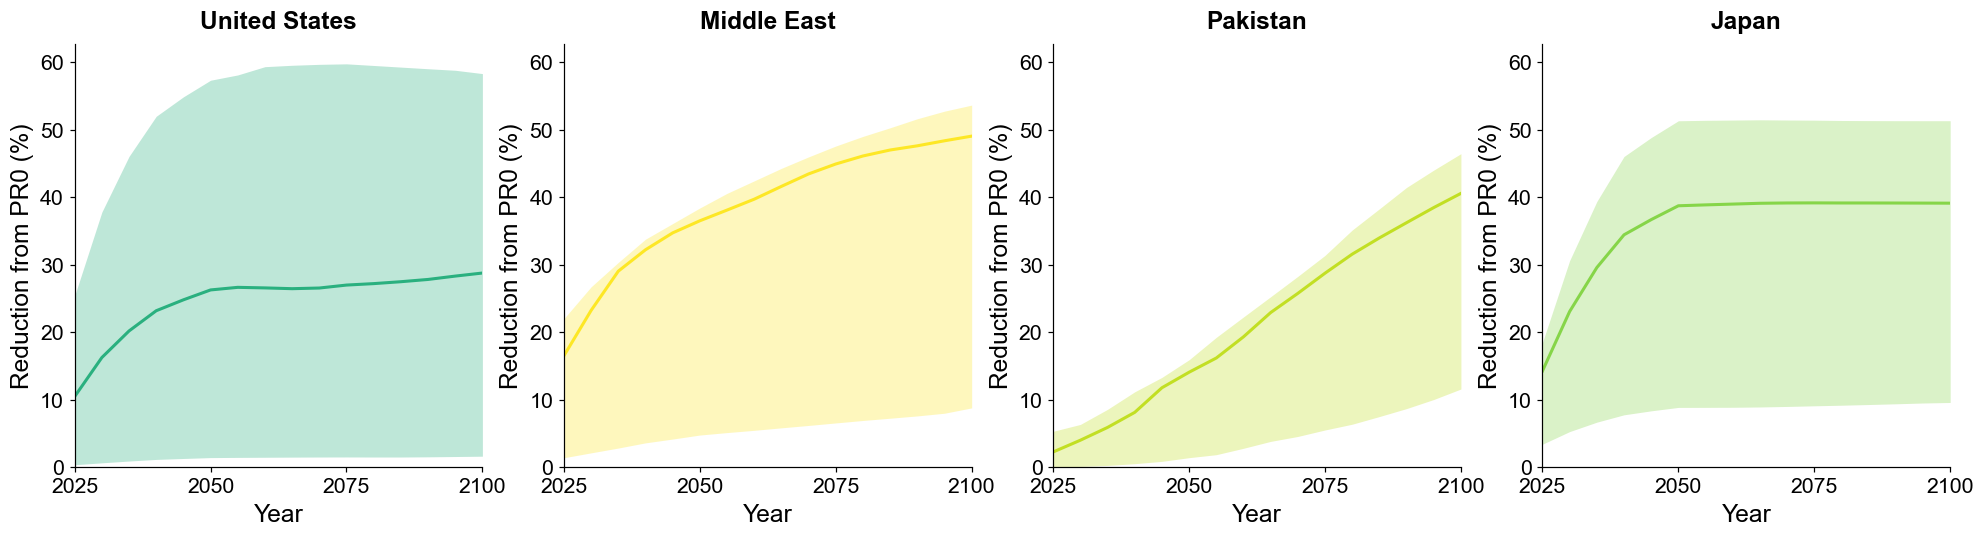

In [11]:
# Per-region colors, taken from the bin palette of the map figure.
# Each color matches that region's median reduction band on the map:
#   USA / United States  ~28.8 %  green   (bin 28-32)
#   Middle East          ~49.1 %  purple  (bin > 44)
#   Pakistan             ~40.6 %  wine    (bin 40-44)
#   Japan                ~39.1 %  mauve   (bin 36-40)
import matplotlib.cm as cm
import matplotlib.colors as mcolors


norm = mcolors.Normalize(vmin=0, vmax=60)
cmap = cm.get_cmap("viridis")

REGION_COLOR = {
    "United States": "#2ab07f",
    "USA":           "#2ab07f",
    "Japan":         "#86d549",
    "Pakistan":      "#c2df23",
    "Middle East":   "#fde725",
}
DEFAULT_COLOR = "#555555"


def plot_region_panel(ax, df_region, title, color):
    """Draw median line plus IQR ribbon for one region."""
    if df_region.empty:
        ax.text(0.5, 0.5, "no data",
                ha="center", va="center",
                transform=ax.transAxes, color="#888780", fontsize=16)
        return

    # IQR ribbon underneath, then the median line on top.
    ax.fill_between(df_region["year"],
                    df_region["q25"], df_region["q75"],
                    color=color, alpha=ALPHA_IQR, linewidth=0)
    ax.plot(df_region["year"], df_region["median"],
            color=color, linewidth=2.0)


    ax.set_title(title, fontweight="bold", pad=10, fontsize=16)
    ax.set_xlabel("Year", fontsize=16)
    ax.set_ylabel("Reduction from PR0 (%)", fontsize=16)
    ax.tick_params(axis="both", labelsize=14)

    ax.set_xlim(START_YEAR, END_YEAR)
    ax.set_xticks([2025, 2050, 2075, 2100])


def figure_2_panels(ens, pr_label, out_stem):
    """1x4 row across the four exemplar regions, each in its own color."""
    available = sorted(ens["region"].unique())

    fig, axes = plt.subplots(
        1, 4, figsize=(22, 5),
        sharex=False, sharey=False,
        gridspec_kw={"wspace": 0.2},
    )

    panel_data = []
    for label, candidates in TARGET_REGIONS:
        match = match_region(candidates, available)
        sub = (ens[ens["region"] == match]
               if match is not None else pd.DataFrame())
        panel_data.append((label, sub))

    if any(not s.empty for _, s in panel_data):
        ymin = min(s["q25"].min() for _, s in panel_data if not s.empty)
        ymax = max(s["q75"].max() for _, s in panel_data if not s.empty)
        pad = 0.05 * (ymax - ymin)
        y_range = (max(0, ymin - pad), ymax + pad)
    else:
        y_range = None

    # Draw each panel in its own region color, falling back to grey
    # if a region label is missing from REGION_COLOR.
    for ax, (label, sub) in zip(axes, panel_data):
        color = REGION_COLOR.get(label, DEFAULT_COLOR)
        plot_region_panel(ax, sub, title=label, color=color)
        if y_range is not None:
            ax.set_ylim(*y_range)

    fig.tight_layout()
    save_all(fig, FIG_DIR, out_stem)
    plt.show()
    plt.close(fig)


figure_2_panels(ens_pr100, "PR100", "fig2abcde_PR100_trajectories_test")